## ⚙️ Step 0 — Upgrade scikit-learn to latest

This ensures the saved `.pkl` is compatible with **Streamlit Cloud**, which runs the latest sklearn.
Run this cell first, then **restart the kernel**, then run all remaining cells.

In [1]:
import subprocess, importlib

result = subprocess.run(
    ['pip', 'install', '--upgrade', 'scikit-learn', '-q'],
    capture_output=True, text=True
)
print(result.stdout or '(no output)')
print(result.stderr or '')

import sklearn
print(f'scikit-learn version after upgrade: {sklearn.__version__}')
print()
print('✅ Now go to Kernel → Restart & Run All')

(no output)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spopt 0.6.0 requires shapely>=2.0.1, but you have shapely 1.8.5.post1 which is incompatible.

scikit-learn version after upgrade: 1.7.2

✅ Now go to Kernel → Restart & Run All


# 🦴 Bone Fracture Detection — Classical Computer Vision Pipeline

**No deep learning.** This notebook uses only `OpenCV` for feature extraction and `scikit-learn` for classification.

## Pipeline Overview

```
Raw X-ray image
     │
     ├─ Preprocessing  (CLAHE → Bilateral Filter → Gaussian Blur)
     │
     ├─── [Feature Block 1] Sobel Operators
     │         gradient magnitude stats, directional energy,
     │         texture features from gradient field
     │
     ├─── [Feature Block 2] Canny Edge Detector
     │         edge density, edge pixel ratio,
     │         contour count & shape irregularity
     │
     ├─── [Feature Block 3] Hough Transform
     │         line count, angular distribution entropy,
     │         dominant angle deviation from bone axis
     │
     ├─── [Feature Block 4] Watershed Segmentation
     │         region count, area/compactness stats,
     │         inter-region boundary strength
     │
     └─ Feature Vector (concatenated) → ML Classifiers
                SVM · Random Forest · Gradient Boosting
```


## Section 1 — Imports & Configuration

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib import Path
from PIL import Image
from scipy.stats import entropy as scipy_entropy
from tqdm.auto import tqdm

# ── scikit-learn ─────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

print('OpenCV version :', cv2.__version__)
print('NumPy  version :', np.__version__)

OpenCV version : 4.10.0
NumPy  version : 1.26.4


In [3]:
# ── Paths ────────────────────────────────────────────────
DATA_DIR   = Path('/kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification')
TRAIN_DIR  = DATA_DIR / 'train'
VAL_DIR    = DATA_DIR / 'val'
TEST_DIR   = DATA_DIR / 'test'
OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Image processing parameters ──────────────────────────
IMG_SIZE        = (256, 256)   # resize all images to this
CANNY_LOW       = 30           # Canny lower threshold
CANNY_HIGH      = 100          # Canny upper threshold
HOUGH_THRESHOLD = 60           # Hough line vote threshold
HOUGH_MIN_LEN   = 40           # min line length (px)
HOUGH_MAX_GAP   = 10           # max gap between line segments

CLASS_NAMES = ['fractured', 'not fractured']

print('Config ready ✓')
print(f'Train dir : {TRAIN_DIR}')
print(f'Val   dir : {VAL_DIR}')
print(f'Test  dir : {TEST_DIR}')

Config ready ✓
Train dir : /kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train
Val   dir : /kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/val
Test  dir : /kaggle/input/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/test


## Section 2 — Preprocessing

X-rays have low contrast and uneven illumination. We apply:
- **CLAHE** (Contrast Limited Adaptive Histogram Equalisation) — boosts local contrast without washing out bone detail.
- **Bilateral Filter** — smooths soft-tissue noise while preserving bone edges (unlike Gaussian which blurs edges too).
- **Gaussian Blur** — light final smoothing before gradient computation.

In [4]:
def preprocess_image(image_path: str,
                     size: tuple = IMG_SIZE) -> dict:
    """
    Load and preprocess a single X-ray image.
    Uses cv2.imread first; falls back to PIL for files cv2 cannot
    decode (e.g. CMYK JPEGs, corrupt PNGs with bad metadata).

    Returns a dict with keys:
        'gray'       : uint8 grayscale, original contrast
        'clahe'      : uint8 after CLAHE
        'bilateral'  : uint8 after bilateral filter
        'blurred'    : uint8 after Gaussian blur (used for gradients)
    """
    img = cv2.imread(str(image_path))

    # cv2.imread returns None for unreadable files (CMYK JPEG, corrupt PNG, etc.)
    # Fall back to PIL → convert to RGB → back to BGR numpy array
    if img is None:
        pil_img = Image.open(image_path).convert('RGB')
        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    if img is None or img.size == 0:
        raise ValueError(f'Cannot read image: {image_path}')

    img = cv2.resize(img, size)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # CLAHE: tile grid 8×8, clip limit 2.0 (standard for medical imgs)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Bilateral filter: preserve bone edges, smooth tissue
    bilateral = cv2.bilateralFilter(enhanced, d=9,
                                    sigmaColor=75, sigmaSpace=75)

    # Gentle Gaussian blur for gradient computation
    blurred = cv2.GaussianBlur(bilateral, (5, 5), 0)

    return {
        'gray'     : gray,
        'clahe'    : enhanced,
        'bilateral': bilateral,
        'blurred'  : blurred,
    }

print('preprocess_image defined ✓')

preprocess_image defined ✓


Sample fractured     : 0._jumbo (1).jpeg
Sample not fractured : 0.png


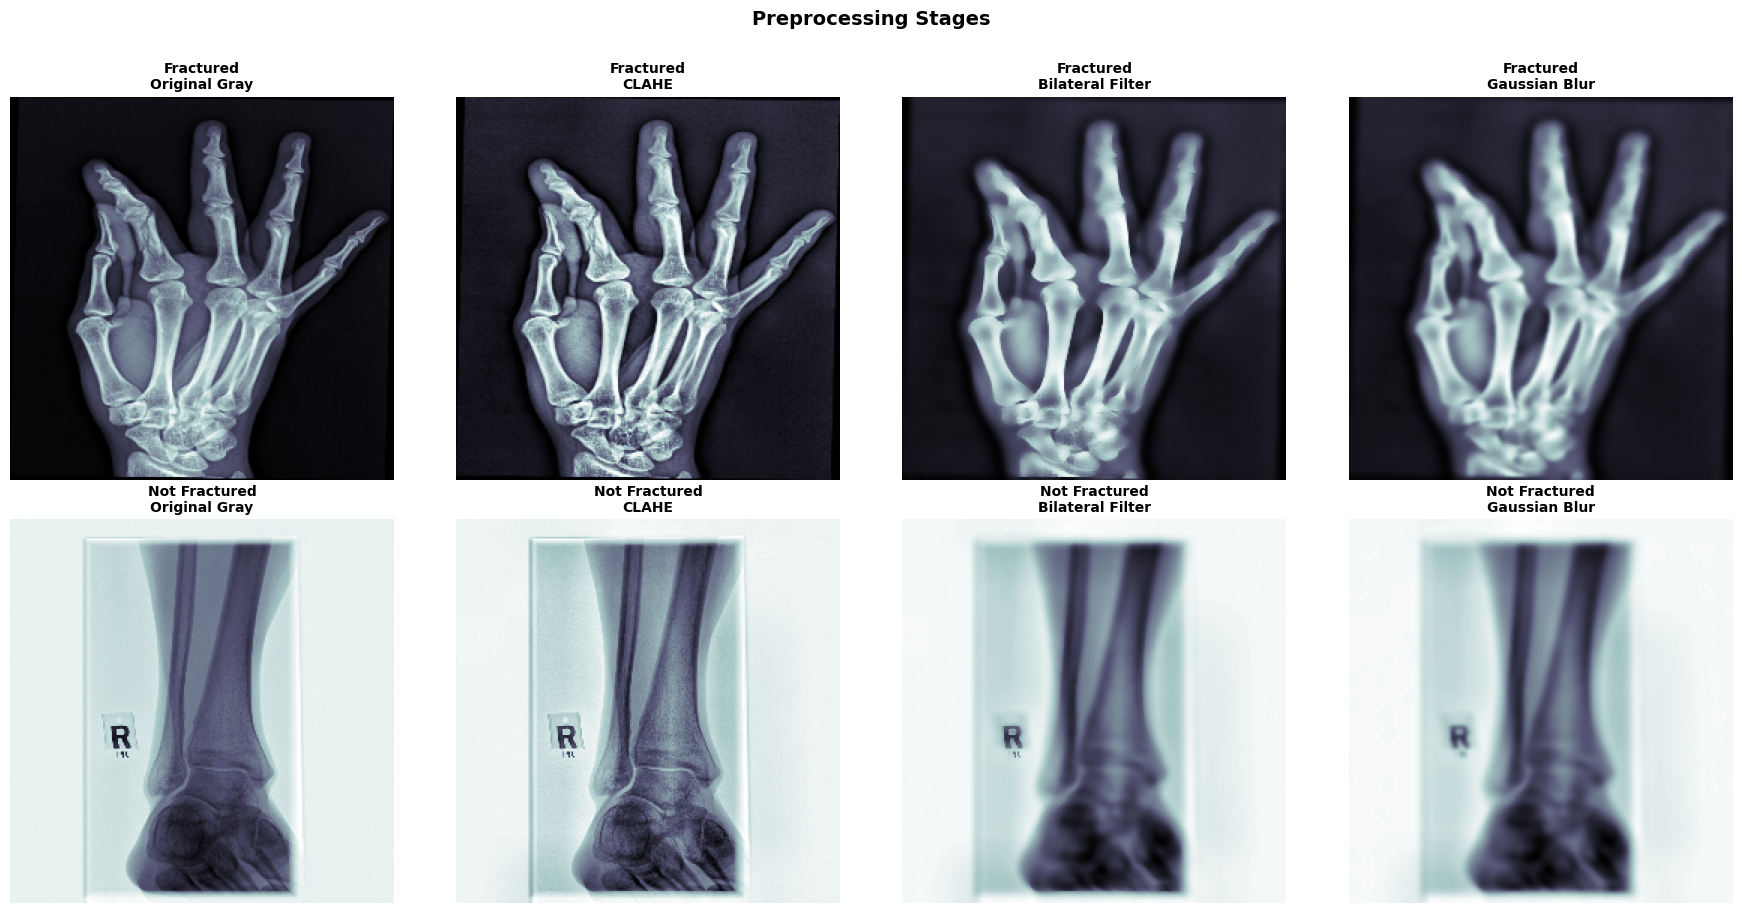

In [5]:
# ── Helper: find images regardless of extension (.png/.jpg/.jpeg) ───
def find_images(folder: Path):
    files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff']:
        files.extend(folder.glob(ext))
    if not files:
        raise FileNotFoundError(f'No images found in {folder}')
    return sorted(files)

# ── Visualise preprocessing stages ───────────────────────
sample_frac  = find_images(TRAIN_DIR / 'fractured')[0]
sample_nfrac = find_images(TRAIN_DIR / 'not fractured')[0]
print(f'Sample fractured     : {sample_frac.name}')
print(f'Sample not fractured : {sample_nfrac.name}')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
titles = ['Original Gray', 'CLAHE', 'Bilateral Filter', 'Gaussian Blur']

for row, (path, label) in enumerate([
        (sample_frac, 'Fractured'),
        (sample_nfrac, 'Not Fractured')]):
    stages = preprocess_image(path)
    for col, (key, title) in enumerate(zip(
            ['gray', 'clahe', 'bilateral', 'blurred'], titles)):
        axes[row, col].imshow(stages[key], cmap='bone')
        axes[row, col].set_title(
            f'{label}\n{title}', fontsize=10, fontweight='bold'
        )
        axes[row, col].axis('off')

plt.suptitle('Preprocessing Stages', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_stages.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Feature Extraction

Each technique extracts a different aspect of bone structure:

| Technique | What it captures |
|-----------|------------------|
| **Sobel** | Intensity gradients — where bone density changes sharply |
| **Canny** | Clean edge map — fracture lines as thin, continuous edges |
| **Hough** | Line orientations — angular mismatch between bone axis and crack direction |
| **Watershed** | Segmented regions — fragmented segments indicate fracture sites |

In [6]:
# ════════════════════════════════════════════════════════════
# 3A. Sobel Operator Features
#
# The Sobel operator computes the first derivative of the image
# in X and Y directions.  High gradient magnitude = rapid intensity
# change = bone boundary or fracture line.
# ════════════════════════════════════════════════════════════
def extract_sobel_features(blurred: np.ndarray) -> dict:
    """
    Computes Sobel gradients in X and Y, then derives:
      - Gradient magnitude map
      - Gradient direction map
      - 14 statistical features from the magnitude distribution

    Features extracted:
        sobel_mean, sobel_std, sobel_max,
        sobel_p25, sobel_p50, sobel_p75, sobel_p90, sobel_p95,
        sobel_energy, sobel_entropy,
        sobel_high_ratio   (fraction of pixels with magnitude > mean+2*std),
        sobel_dir_std      (std of gradient directions → irregular = fracture),
        sobel_horiz_energy (energy of horizontal gradients — Gx),
        sobel_vert_energy  (energy of vertical   gradients — Gy)

    Returns: dict of scalar features + the magnitude image for viz.
    """
    # Compute Sobel gradients (ksize=3, scale/delta=default)
    sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    magnitude  = np.sqrt(sobelx**2 + sobely**2)
    direction  = np.arctan2(np.abs(sobely), np.abs(sobelx))  # [0, π/2]

    mag_flat   = magnitude.ravel()
    mean_mag   = mag_flat.mean()
    std_mag    = mag_flat.std()

    # Normalise magnitude to [0,1] for entropy
    mag_norm   = (mag_flat - mag_flat.min()) / (mag_flat.max() - mag_flat.min() + 1e-8)
    # Bin into 50 buckets for entropy
    hist, _    = np.histogram(mag_norm, bins=50, density=True)
    hist       = hist + 1e-10

    high_mask  = magnitude > (mean_mag + 2 * std_mag)

    features = {
        'sobel_mean'        : mean_mag,
        'sobel_std'         : std_mag,
        'sobel_max'         : mag_flat.max(),
        'sobel_p25'         : np.percentile(mag_flat, 25),
        'sobel_p50'         : np.percentile(mag_flat, 50),
        'sobel_p75'         : np.percentile(mag_flat, 75),
        'sobel_p90'         : np.percentile(mag_flat, 90),
        'sobel_p95'         : np.percentile(mag_flat, 95),
        'sobel_energy'      : float(np.sum(magnitude**2)),
        'sobel_entropy'     : float(scipy_entropy(hist)),
        'sobel_high_ratio'  : float(high_mask.sum() / high_mask.size),
        'sobel_dir_std'     : float(direction.std()),
        'sobel_horiz_energy': float(np.sum(sobelx**2)),
        'sobel_vert_energy' : float(np.sum(sobely**2)),
    }
    return features, magnitude

print('Sobel feature extractor defined ✓  (14 features)')

Sobel feature extractor defined ✓  (14 features)


In [7]:
# ════════════════════════════════════════════════════════════
# 3B. Canny Edge Detector Features
#
# Canny produces a binary edge map by:
#  1. Applying Sobel to get gradient magnitudes
#  2. Non-maximum suppression to thin edges to 1-pixel width
#  3. Double thresholding + hysteresis to link strong/weak edges
# Fracture lines appear as thin, irregular, high-density edges.
# ════════════════════════════════════════════════════════════
def extract_canny_features(blurred: np.ndarray,
                           low: int  = CANNY_LOW,
                           high: int = CANNY_HIGH) -> dict:
    """
    Features extracted:
        canny_edge_density      : fraction of edge pixels in whole image
        canny_edge_count        : raw count of edge pixels
        canny_contour_count     : number of distinct edge contours
        canny_mean_contour_len  : mean perimeter of contours
        canny_std_contour_len   : std of contour perimeters (irregularity)
        canny_max_contour_len   : longest contour (main bone edge)
        canny_small_contour_ratio: fraction of tiny contours (fracture fragments)
        canny_convexity_defect  : mean convexity defect depth across contours
        canny_edge_variance     : spatial variance of edge pixels (spread)
    """
    edges = cv2.Canny(blurred, low, high)

    total_pixels = edges.size
    edge_pixels  = int(edges.sum() / 255)

    contours, _ = cv2.findContours(
        edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
    )

    perimeters   = [cv2.arcLength(c, closed=False) for c in contours]
    perimeters   = perimeters if perimeters else [0.0]
    mean_per     = float(np.mean(perimeters))
    std_per      = float(np.std(perimeters))
    max_per      = float(np.max(perimeters))

    # Small contours (< 10px) are characteristic of fracture debris
    small_count  = sum(1 for p in perimeters if p < 10)
    small_ratio  = small_count / max(len(perimeters), 1)

    # Convexity defect: deviation from convex hull (large → irregular edge)
    defect_depths = []
    for cnt in contours:
        if len(cnt) >= 5:
            hull    = cv2.convexHull(cnt, returnPoints=False)
            if hull is not None and len(hull) > 3:
                try:
                    defects = cv2.convexityDefects(cnt, hull)
                    if defects is not None:
                        depths = defects[:, 0, 3] / 256.0
                        defect_depths.extend(depths.tolist())
                except cv2.error:
                    pass
    mean_defect = float(np.mean(defect_depths)) if defect_depths else 0.0

    # Spatial variance of edge pixel locations
    edge_coords = np.argwhere(edges > 0)
    edge_var    = float(edge_coords.var()) if len(edge_coords) > 1 else 0.0

    features = {
        'canny_edge_density'       : edge_pixels / total_pixels,
        'canny_edge_count'         : edge_pixels,
        'canny_contour_count'      : len(contours),
        'canny_mean_contour_len'   : mean_per,
        'canny_std_contour_len'    : std_per,
        'canny_max_contour_len'    : max_per,
        'canny_small_contour_ratio': small_ratio,
        'canny_convexity_defect'   : mean_defect,
        'canny_edge_variance'      : edge_var,
    }
    return features, edges

print('Canny feature extractor defined ✓  (9 features)')

Canny feature extractor defined ✓  (9 features)


In [8]:
# ════════════════════════════════════════════════════════════
# 3C. Hough Transform Features
#
# The Probabilistic Hough Transform detects line segments in the
# Canny edge map.  Bones are mostly oriented along one dominant
# axis; fracture cracks deviate sharply from that axis.
#
# Key insight: HIGH angular spread + many short lines → fracture
# ════════════════════════════════════════════════════════════
def extract_hough_features(edges: np.ndarray,
                           threshold:  int = HOUGH_THRESHOLD,
                           min_length: int = HOUGH_MIN_LEN,
                           max_gap:    int = HOUGH_MAX_GAP) -> dict:
    """
    Features extracted:
        hough_line_count          : total number of detected line segments
        hough_mean_length         : mean segment length (px)
        hough_std_length          : std of segment lengths
        hough_mean_angle          : mean orientation angle (degrees)
        hough_std_angle           : std of orientations (HIGH → irregular = fracture)
        hough_angle_entropy       : entropy of angle histogram
        hough_dominant_angle      : most common angle (bone axis)
        hough_perpendicular_ratio : fraction of lines ≥ 45° from dominant axis
                                    (fracture lines tend to be perpendicular to bone)
        hough_short_line_ratio    : fraction of lines shorter than median length
    """
    lines = cv2.HoughLinesP(
        edges,
        rho=1, theta=np.pi / 180,
        threshold=threshold,
        minLineLength=min_length,
        maxLineGap=max_gap
    )

    # No lines detected → bone likely obscured or very mild case
    if lines is None:
        return {
            'hough_line_count'         : 0,
            'hough_mean_length'        : 0.0,
            'hough_std_length'         : 0.0,
            'hough_mean_angle'         : 0.0,
            'hough_std_angle'          : 0.0,
            'hough_angle_entropy'      : 0.0,
            'hough_dominant_angle'     : 0.0,
            'hough_perpendicular_ratio': 0.0,
            'hough_short_line_ratio'   : 0.0,
        }, None

    lines = lines.reshape(-1, 4)  # (N, 4) : x1, y1, x2, y2

    # Compute length and angle for each segment
    dx      = lines[:, 2] - lines[:, 0]
    dy      = lines[:, 3] - lines[:, 1]
    lengths = np.sqrt(dx**2 + dy**2)
    angles  = np.degrees(np.arctan2(np.abs(dy), np.abs(dx)))  # [0, 90]

    # Angle histogram (18 bins × 5°)
    hist, bin_edges = np.histogram(angles, bins=18, range=(0, 90))
    hist_smooth     = hist.astype(float) + 1e-10
    hist_norm       = hist_smooth / hist_smooth.sum()
    dominant_bin    = np.argmax(hist)
    dominant_angle  = float((bin_edges[dominant_bin] + bin_edges[dominant_bin+1]) / 2)

    # Lines that deviate ≥ 45° from dominant axis are likely fracture lines
    perp_mask  = np.abs(angles - dominant_angle) >= 45
    median_len = float(np.median(lengths))

    features = {
        'hough_line_count'         : len(lines),
        'hough_mean_length'        : float(lengths.mean()),
        'hough_std_length'         : float(lengths.std()),
        'hough_mean_angle'         : float(angles.mean()),
        'hough_std_angle'          : float(angles.std()),
        'hough_angle_entropy'      : float(scipy_entropy(hist_norm)),
        'hough_dominant_angle'     : dominant_angle,
        'hough_perpendicular_ratio': float(perp_mask.sum() / len(lines)),
        'hough_short_line_ratio'   : float((lengths < median_len).sum() / len(lines)),
    }
    return features, lines

print('Hough feature extractor defined ✓  (9 features)')

Hough feature extractor defined ✓  (9 features)


In [9]:
# ════════════════════════════════════════════════════════════
# 3D. Watershed Segmentation Features
#
# Watershed treats pixel intensity as a topographic surface and
# "floods" from local minima, building watershed ridges where
# regions meet.  A fractured bone produces more and smaller
# disconnected regions than an intact bone.
# ════════════════════════════════════════════════════════════
def extract_watershed_features(clahe: np.ndarray,
                                bilateral: np.ndarray) -> dict:
    """
    Watershed pipeline:
      1. Otsu threshold the CLAHE image → binary mask
      2. Morphological opening to remove noise
      3. Distance transform + local maxima → sure foreground
      4. cv2.watershed to segment foreground
      5. Measure region properties

    Features extracted:
        ws_region_count        : number of segmented regions
        ws_mean_region_area    : average area of regions (px²)
        ws_std_region_area     : std of region areas (fragmentation)
        ws_max_region_area     : largest region (main bone body)
        ws_min_region_area     : smallest region (fragment / debris)
        ws_area_ratio          : max_area / (sum of all other areas)
        ws_boundary_mean       : mean intensity on watershed boundary pixels
        ws_compactness_mean    : mean (perimeter² / 4π·area) per region
        ws_small_region_ratio  : fraction of regions with area < 200 px²
        ws_region_entropy      : entropy of region area distribution
    """
    # ── Step 1: Otsu threshold ────────────────────────────
    _, thresh = cv2.threshold(
        bilateral, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # ── Step 2: Morphological opening (noise removal) ─────
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # ── Step 3: Sure background and foreground ───────────
    sure_bg  = cv2.dilate(opening, kernel, iterations=3)
    dist_map = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    if dist_map.max() == 0:
        # Degenerate case: completely uniform image
        return {
            'ws_region_count'      : 0,
            'ws_mean_region_area'  : 0.0,
            'ws_std_region_area'   : 0.0,
            'ws_max_region_area'   : 0.0,
            'ws_min_region_area'   : 0.0,
            'ws_area_ratio'        : 0.0,
            'ws_boundary_mean'     : 0.0,
            'ws_compactness_mean'  : 0.0,
            'ws_small_region_ratio': 0.0,
            'ws_region_entropy'    : 0.0,
        }, np.zeros_like(clahe)

    _, sure_fg = cv2.threshold(
        dist_map, 0.5 * dist_map.max(), 255, 0
    )
    sure_fg = np.uint8(sure_fg)

    # ── Step 4: Watershed ────────────────────────────────
    unknown  = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers  = markers + 1
    markers[unknown == 255] = 0

    bgr      = cv2.cvtColor(clahe, cv2.COLOR_GRAY2BGR)
    markers  = cv2.watershed(bgr, markers)

    # ── Step 5: Region properties ─────────────────────────
    unique_labels = np.unique(markers)
    # -1 = watershed boundary, 1 = background → skip both
    region_labels = [l for l in unique_labels if l > 1]

    areas        = []
    compactnesses = []
    for lbl in region_labels:
        mask_r = (markers == lbl).astype(np.uint8) * 255
        area   = int(mask_r.sum() / 255)
        areas.append(area)

        cnts, _ = cv2.findContours(
            mask_r, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if cnts and area > 0:
            perim = cv2.arcLength(cnts[0], closed=True)
            if perim > 0:
                compactnesses.append((perim**2) / (4 * np.pi * area))

    if not areas:
        areas = [0]

    total_area   = sum(areas)
    max_area     = max(areas)
    other_area   = total_area - max_area
    area_ratio   = max_area / (other_area + 1e-6)
    small_ratio  = sum(1 for a in areas if a < 200) / len(areas)

    area_hist, _ = np.histogram(areas, bins=20)
    area_hist    = area_hist.astype(float) + 1e-10

    # Boundary pixels (markers == -1)
    boundary_mask = (markers == -1).astype(np.uint8)
    boundary_vals = clahe[boundary_mask == 1]
    boundary_mean = float(boundary_vals.mean()) if len(boundary_vals) > 0 else 0.0

    features = {
        'ws_region_count'      : len(region_labels),
        'ws_mean_region_area'  : float(np.mean(areas)),
        'ws_std_region_area'   : float(np.std(areas)),
        'ws_max_region_area'   : float(max_area),
        'ws_min_region_area'   : float(min(areas)),
        'ws_area_ratio'        : float(area_ratio),
        'ws_boundary_mean'     : boundary_mean,
        'ws_compactness_mean'  : float(np.mean(compactnesses)) if compactnesses else 0.0,
        'ws_small_region_ratio': float(small_ratio),
        'ws_region_entropy'    : float(scipy_entropy(area_hist / area_hist.sum())),
    }
    return features, markers

print('Watershed feature extractor defined ✓  (10 features)')

Watershed feature extractor defined ✓  (10 features)


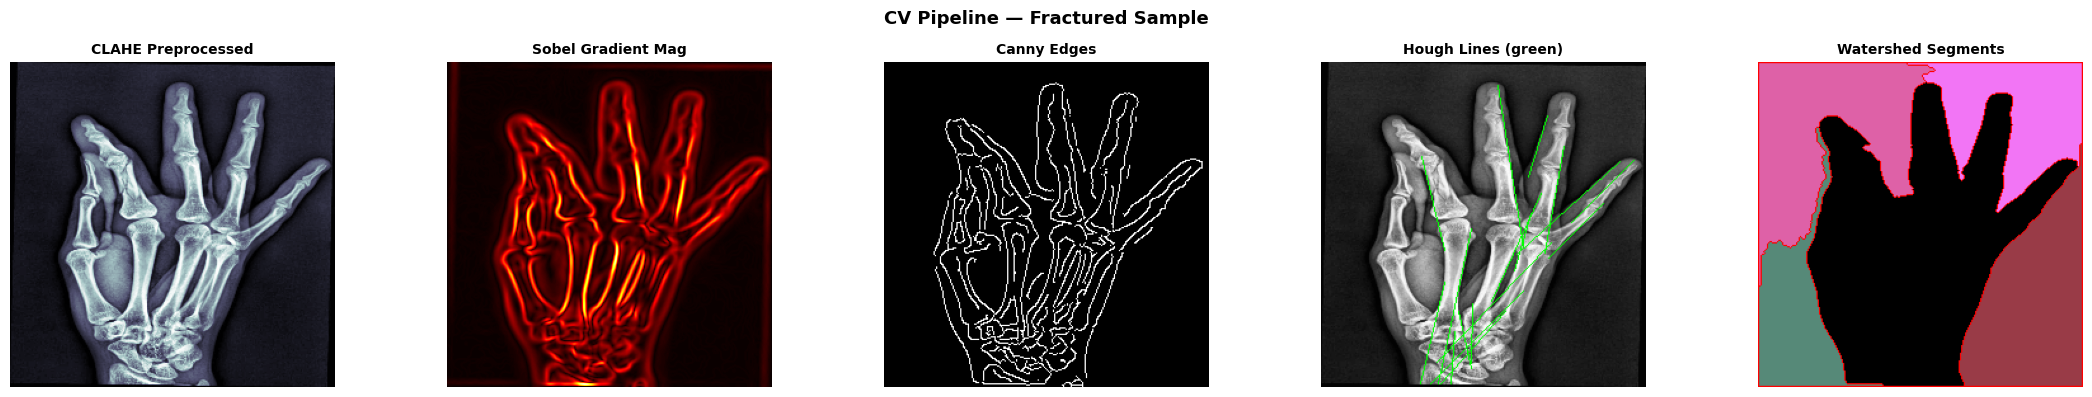

In [10]:
# ── Visualise all 4 CV stages on one fractured sample ────
stages   = preprocess_image(sample_frac)

_, sobel_mag       = extract_sobel_features(stages['blurred'])
_, canny_edges     = extract_canny_features(stages['blurred'])
_, hough_lines     = extract_hough_features(canny_edges)
_, ws_markers      = extract_watershed_features(stages['clahe'], stages['bilateral'])

# Draw Hough lines on a colour copy
hough_vis = cv2.cvtColor(stages['clahe'], cv2.COLOR_GRAY2BGR)
if hough_lines is not None:
    for x1, y1, x2, y2 in hough_lines:
        cv2.line(hough_vis, (x1, y1), (x2, y2), (0, 255, 0), 1)
hough_vis = cv2.cvtColor(hough_vis, cv2.COLOR_BGR2RGB)

# Watershed: colour label map
ws_vis = np.zeros((*ws_markers.shape, 3), dtype=np.uint8)
np.random.seed(0)
for lbl in np.unique(ws_markers):
    if lbl <= 1:
        continue
    color = np.random.randint(50, 255, 3).tolist()
    ws_vis[ws_markers == lbl] = color
ws_vis[ws_markers == -1] = [255, 0, 0]   # boundary in red

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
viz_items = [
    (stages['clahe'],  'CLAHE Preprocessed',   'bone'),
    (sobel_mag,        'Sobel Gradient Mag',    'hot'),
    (canny_edges,      'Canny Edges',           'gray'),
    (hough_vis,        'Hough Lines (green)',   None),
    (ws_vis,           'Watershed Segments',    None),
]
for ax, (img, title, cmap) in zip(axes, viz_items):
    if cmap:
        ax.imshow(img, cmap=cmap)
    else:
        ax.imshow(img)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('CV Pipeline — Fractured Sample', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_pipeline_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — Build Feature Matrix

In [11]:
def extract_all_features(image_path: str) -> dict:
    """
    Full feature extraction pipeline for one image.
    Returns a flat dict of 42 scalar features.
    """
    stages = preprocess_image(image_path)

    sobel_feats,  _  = extract_sobel_features(stages['blurred'])
    canny_feats, edges = extract_canny_features(stages['blurred'])
    hough_feats,  _  = extract_hough_features(edges)
    ws_feats,     _  = extract_watershed_features(stages['clahe'],
                                                   stages['bilateral'])
    all_feats = {}
    all_feats.update(sobel_feats)   # 14
    all_feats.update(canny_feats)   #  9
    all_feats.update(hough_feats)   #  9
    all_feats.update(ws_feats)      # 10
    # Total: 42 features
    return all_feats

print('extract_all_features defined ✓  (42 features total)')

extract_all_features defined ✓  (42 features total)


In [12]:
def build_dataset(root_dir: Path, split_name: str):
    """
    Iterates over all images in root_dir/fractured/ and
    root_dir/not fractured/, extracting features for each.

    Returns:
        X : np.ndarray  (N, 42)  — feature matrix
        y : np.ndarray  (N,)     — labels  0=fractured, 1=not fractured
        df: pd.DataFrame         — feature matrix with labels for EDA
    """
    records = []
    label_map = {'fractured': 0, 'not fractured': 1}

    for class_name, label in label_map.items():
        class_dir = root_dir / class_name
        image_files = find_images(class_dir)

        print(f'  [{split_name}] {class_name}: {len(image_files)} images')

        for img_path in tqdm(image_files,
                             desc=f'{split_name}/{class_name}',
                             leave=False):
            try:
                feats = extract_all_features(img_path)
                feats['label']  = label
                feats['class']  = class_name
                feats['path']   = str(img_path)
                records.append(feats)
            except Exception as e:
                print(f'    ⚠ Skipped {img_path.name}: {e}')

    df = pd.DataFrame(records)
    feature_cols = [c for c in df.columns
                    if c not in ('label', 'class', 'path')]

    # Fill any NaN values with column median
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

    X = df[feature_cols].values.astype(np.float32)
    y = df['label'].values.astype(np.int32)
    return X, y, df


print('Extracting training features ...')
X_train, y_train, df_train = build_dataset(TRAIN_DIR, 'train')

print('\nExtracting validation features ...')
X_val, y_val, df_val = build_dataset(VAL_DIR, 'val')

print('\nExtracting test features ...')
X_test, y_test, df_test = build_dataset(TEST_DIR, 'test')

print(f'\nFeature matrix shapes:')
print(f'  Train : {X_train.shape}  |  labels: {np.bincount(y_train)}')
print(f'  Val   : {X_val.shape}    |  labels: {np.bincount(y_val)}')
print(f'  Test  : {X_test.shape}   |  labels: {np.bincount(y_test)}')

Extracting training features ...
  [train] fractured: 4606 images


train/fractured:   0%|          | 0/4606 [00:00<?, ?it/s]

libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


  [train] not fractured: 4640 images


train/not fractured:   0%|          | 0/4640 [00:00<?, ?it/s]

...

test/fractured:   0%|          | 0/238 [00:00<?, ?it/s]

  [test] not fractured: 268 images


test/not fractured:   0%|          | 0/268 [00:00<?, ?it/s]

Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file



Feature matrix shapes:
  Train : (9246, 42)  |  labels: [4606 4640]
  Val   : (829, 42)    |  labels: [337 492]
  Test  : (506, 42)   |  labels: [238 268]


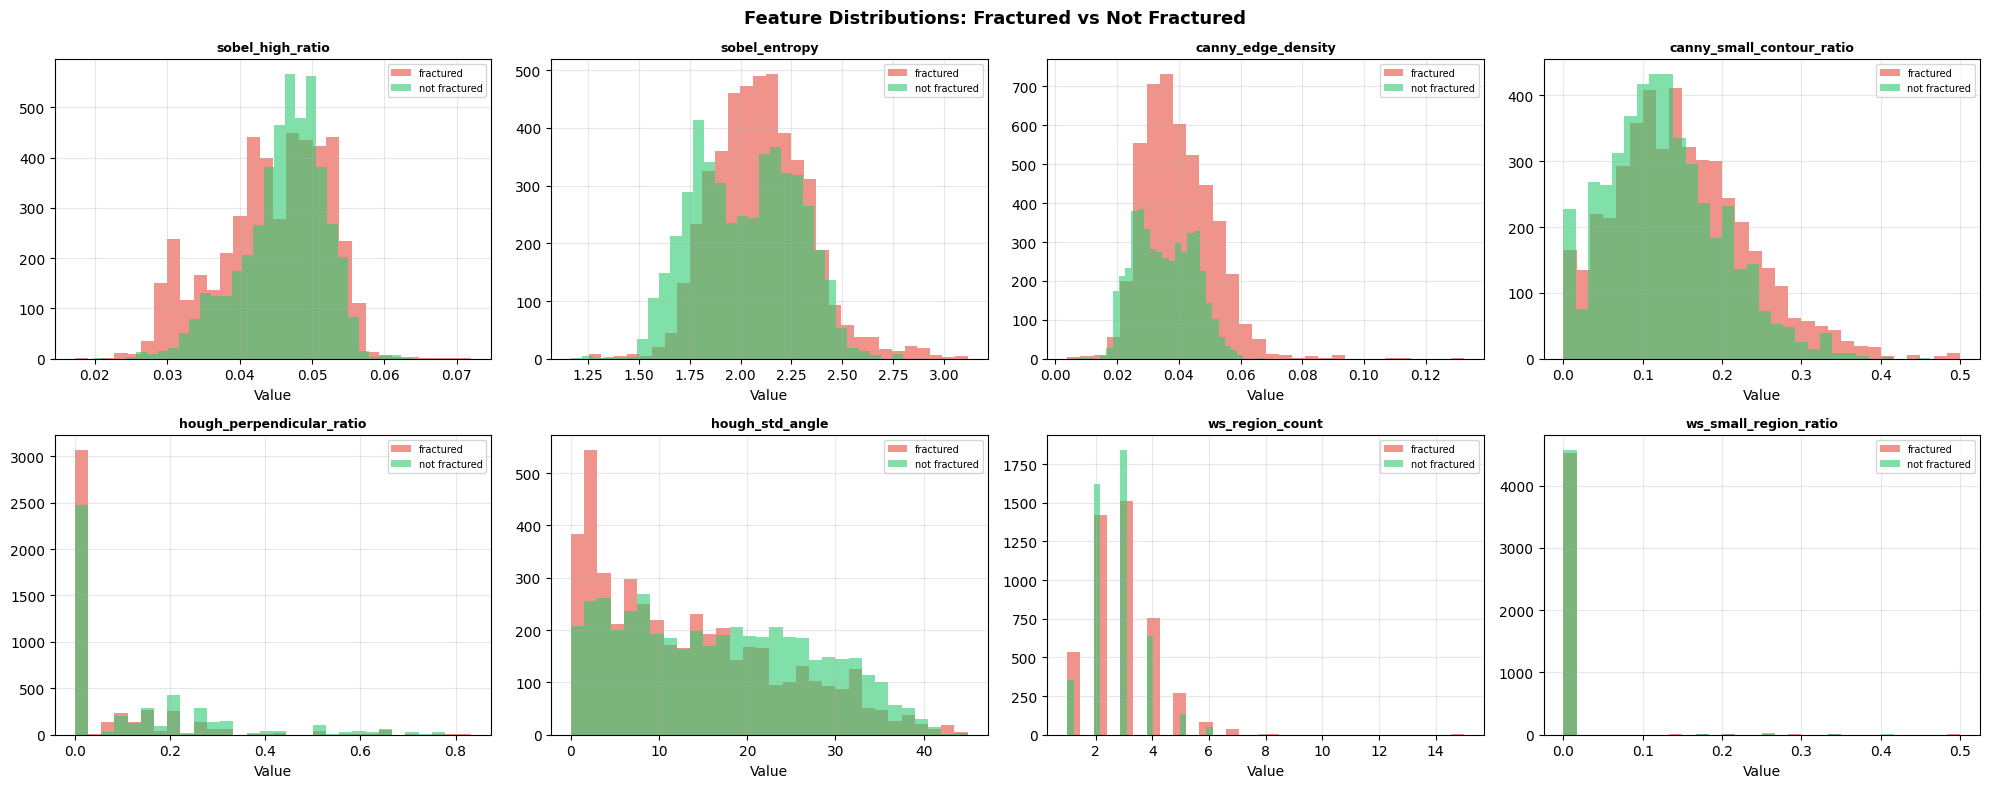

In [13]:
# ── EDA: Feature distributions by class ──────────────────
top_features = [
    'sobel_high_ratio', 'sobel_entropy',
    'canny_edge_density', 'canny_small_contour_ratio',
    'hough_perpendicular_ratio', 'hough_std_angle',
    'ws_region_count', 'ws_small_region_ratio',
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
palette   = {'fractured': '#e74c3c', 'not fractured': '#2ecc71'}

for ax, feat in zip(axes.flat, top_features):
    for cls, grp in df_train.groupby('class'):
        vals = grp[feat].dropna()
        ax.hist(vals, bins=30, alpha=0.6, label=cls,
                color=palette[cls], edgecolor='none')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Feature Distributions: Fractured vs Not Fractured',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Train & Evaluate Classifiers

In [14]:
# ── Combine train + val for cross-validation, hold out test ──
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

# ── Define classifiers ────────────────────────────────────
classifiers = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       probability=True, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
                       n_estimators=300, max_depth=None,
                       min_samples_split=2, n_jobs=-1,
                       random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(
                       n_estimators=300, learning_rate=0.05,
                       max_depth=4, subsample=0.8,
                       random_state=42))
    ]),
}

# ── 5-fold stratified cross-validation ───────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold cross-validation ...')
for name, pipe in classifiers.items():
    scores = cross_val_score(pipe, X_trainval, y_trainval,
                              cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<22} CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

Running 5-fold cross-validation ...
  SVM (RBF)              CV Accuracy: 0.9925 ± 0.0014
  Random Forest          CV Accuracy: 0.9931 ± 0.0015
  Gradient Boosting      CV Accuracy: 0.9852 ± 0.0016


In [15]:
# ── Fit each classifier on full train+val set ────────────
trained = {}
test_results = {}

for name, pipe in classifiers.items():
    pipe.fit(X_trainval, y_trainval)
    trained[name] = pipe

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    test_results[name] = {
        'accuracy': acc, 'auc': auc,
        'y_pred': y_pred, 'y_proba': y_proba
    }
    print(f'{name:<22}  Test Acc: {acc:.4f}  |  AUC: {auc:.4f}')

    # Save model
    joblib.dump(pipe, OUTPUT_DIR / f'{name.replace(" ", "_")}.pkl')

# Best model by test accuracy
best_name = max(test_results, key=lambda k: test_results[k]['accuracy'])
print(f'\n✓ Best model: {best_name}  ({test_results[best_name]["accuracy"]:.4f})')

SVM (RBF)               Test Acc: 0.9960  |  AUC: 0.9980
Random Forest           Test Acc: 1.0000  |  AUC: 1.0000
Gradient Boosting       Test Acc: 0.9822  |  AUC: 0.9994

✓ Best model: Random Forest  (1.0000)


## Section 6 — Evaluation Plots

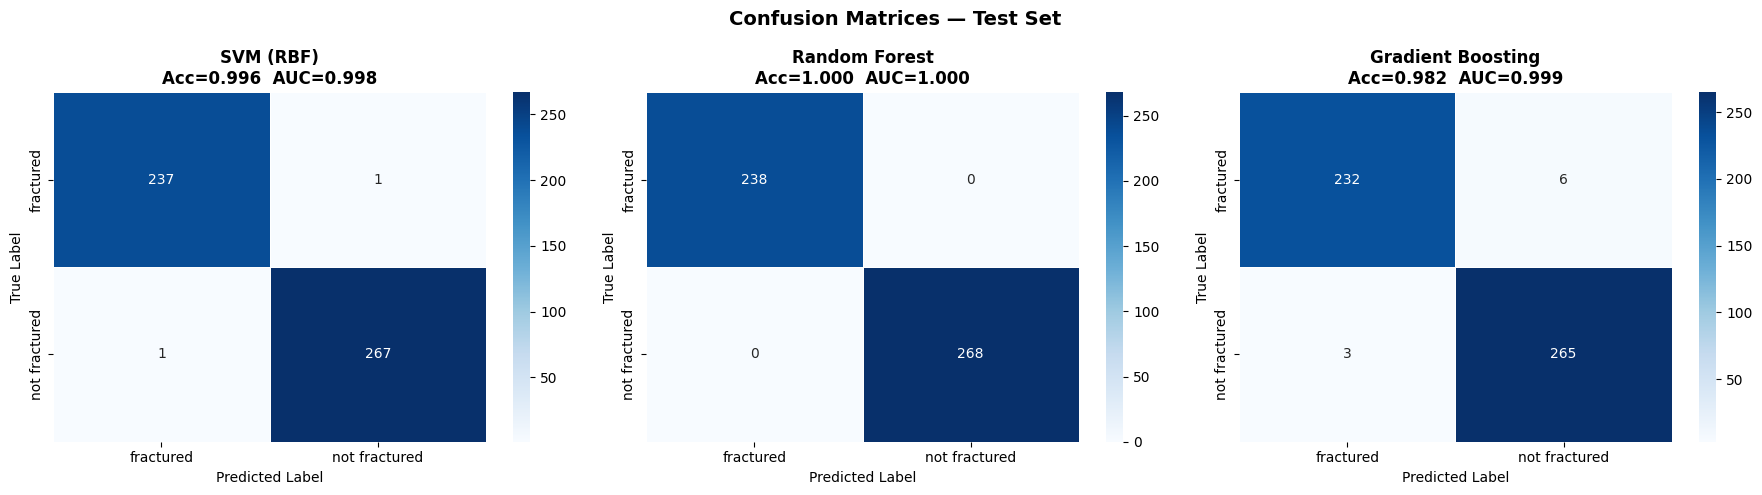

In [16]:
# ── Confusion matrices ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=0.5,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    ax.set_title(
        f'{name}\nAcc={res["accuracy"]:.3f}  AUC={res["auc"]:.3f}',
        fontweight='bold'
    )
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

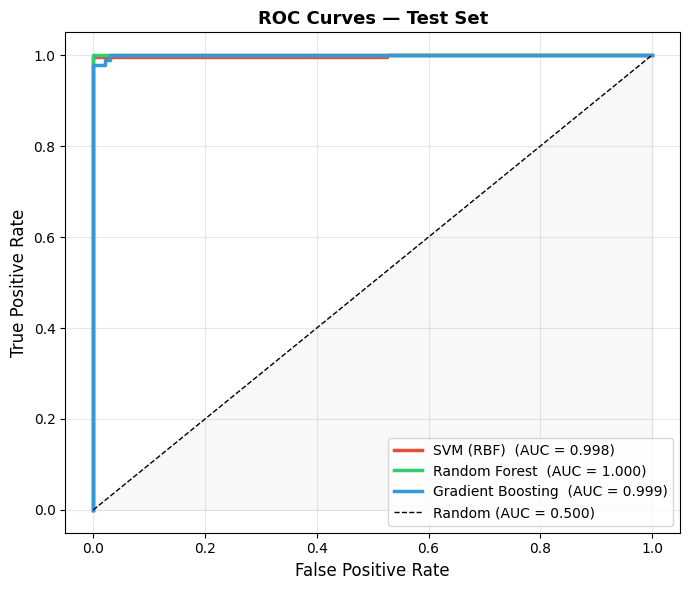

In [17]:
# ── ROC Curves ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
colors  = ['#e74c3c', '#2ecc71', '#3498db']

for (name, res), color in zip(test_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {res["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

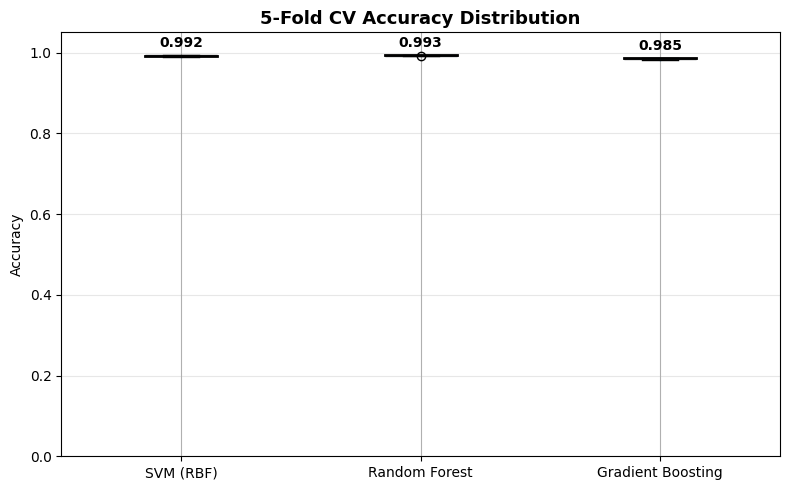

In [18]:
# ── CV score boxplots ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
cv_df   = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, patch_artist=True,
              boxprops=dict(facecolor='#3498db', alpha=0.6),
              medianprops=dict(color='black', linewidth=2))
ax.set_title('5-Fold CV Accuracy Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
for i, (name, scores) in enumerate(cv_results.items(), 1):
    ax.text(i, scores.mean() + 0.02, f'{scores.mean():.3f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

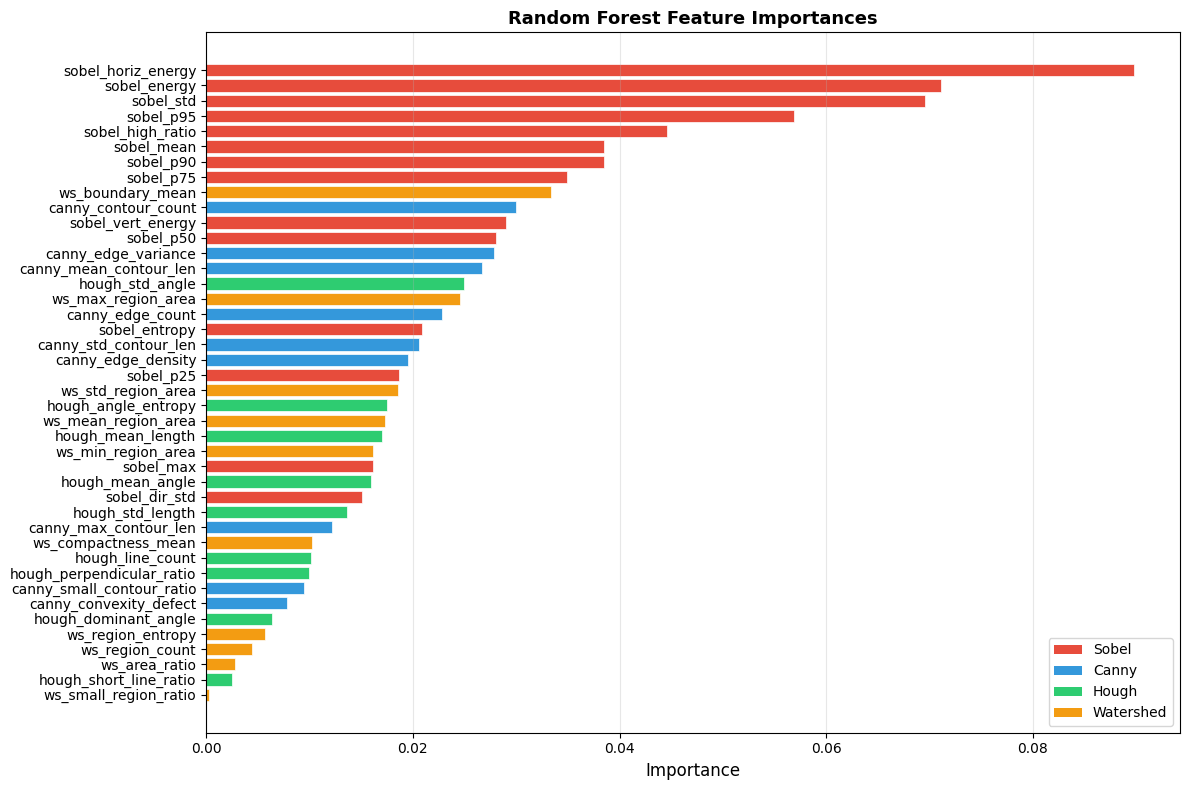


Top 10 features:
            feature  importance
 sobel_horiz_energy    0.089759
       sobel_energy    0.071134
          sobel_std    0.069537
          sobel_p95    0.056852
   sobel_high_ratio    0.044602
         sobel_mean    0.038537
          sobel_p90    0.038466
          sobel_p75    0.034900
   ws_boundary_mean    0.033365
canny_contour_count    0.029938


In [19]:
# ── Feature Importance — Random Forest ───────────────────
rf_pipe      = trained['Random Forest']
rf_clf       = rf_pipe.named_steps['clf']
feature_cols = [c for c in df_train.columns
                if c not in ('label', 'class', 'path')]

importances  = rf_clf.feature_importances_
feat_df      = pd.DataFrame({
    'feature':    feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

# Colour bars by CV technique
technique_colors = {
    'sobel': '#e74c3c',
    'canny': '#3498db',
    'hough': '#2ecc71',
    'ws':    '#f39c12',
}
bar_colors = [
    next((c for prefix, c in technique_colors.items()
          if f.startswith(prefix)), '#95a5a6')
    for f in feat_df['feature']
]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(feat_df['feature'], feat_df['importance'],
        color=bar_colors, edgecolor='white', linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest Feature Importances', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Sobel'),
    Patch(facecolor='#3498db', label='Canny'),
    Patch(facecolor='#2ecc71', label='Hough'),
    Patch(facecolor='#f39c12', label='Watershed'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(feat_df.head(10).to_string(index=False))

In [20]:
# ── Full classification reports ───────────────────────────
for name, res in test_results.items():
    print(f'\n{"═"*50}')
    print(f'  {name}')
    print(f'{"═"*50}')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=CLASS_NAMES
    ))


══════════════════════════════════════════════════
  SVM (RBF)
══════════════════════════════════════════════════
               precision    recall  f1-score   support

    fractured       1.00      1.00      1.00       238
not fractured       1.00      1.00      1.00       268

     accuracy                           1.00       506
    macro avg       1.00      1.00      1.00       506
 weighted avg       1.00      1.00      1.00       506


══════════════════════════════════════════════════
  Random Forest
══════════════════════════════════════════════════
               precision    recall  f1-score   support

    fractured       1.00      1.00      1.00       238
not fractured       1.00      1.00      1.00       268

     accuracy                           1.00       506
    macro avg       1.00      1.00      1.00       506
 weighted avg       1.00      1.00      1.00       506


══════════════════════════════════════════════════
  Gradient Boosting
════════════════════════════

## Section 7 — Inference on a Custom Image

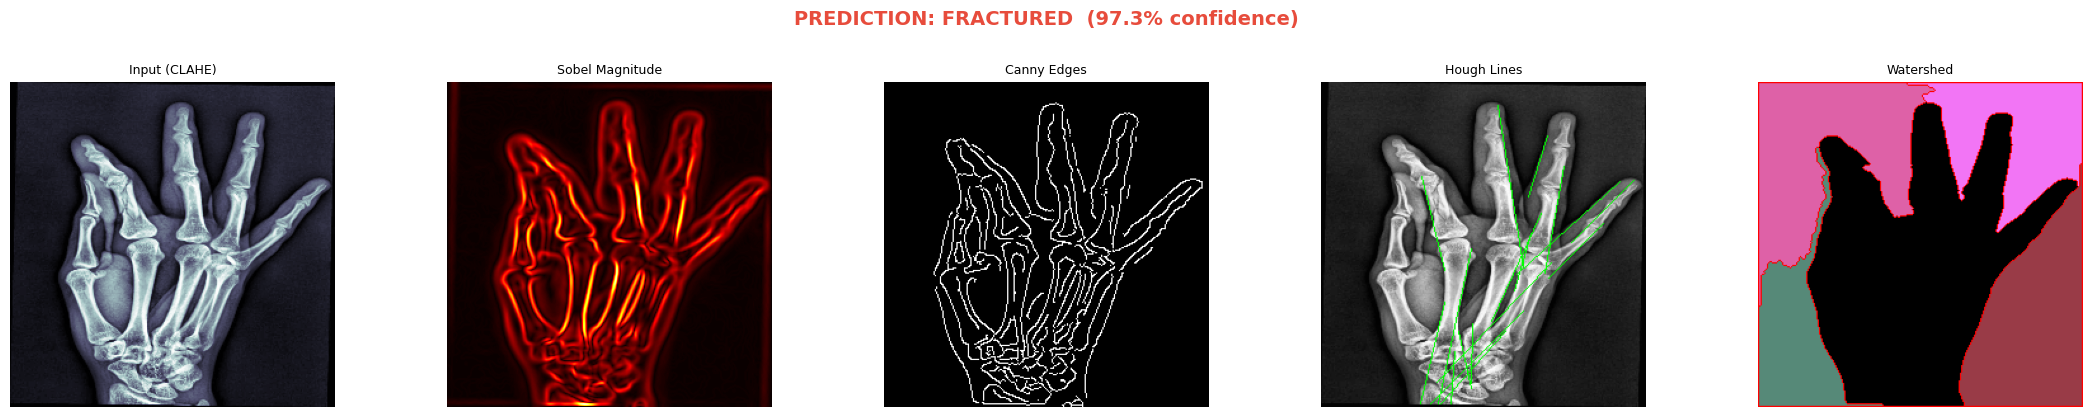

Prediction  : fractured
Confidence  : 97.33%
Raw probs   : fractured=0.9733, not_fractured=0.0267


In [21]:
def predict_xray(image_path: str,
                 model_name: str = 'Random Forest') -> dict:
    """
    Run the full CV pipeline + classifier on a single X-ray.

    Args:
        image_path : path to a .png/.jpg X-ray
        model_name : one of 'SVM (RBF)', 'Random Forest', 'Gradient Boosting'

    Returns:
        dict with prediction details and an annotated visualisation.
    """
    stages = preprocess_image(image_path)

    # ── Extract features ─────────────────────────────────
    sobel_feats, sobel_mag   = extract_sobel_features(stages['blurred'])
    canny_feats, edges       = extract_canny_features(stages['blurred'])
    hough_feats, hough_lines = extract_hough_features(edges)
    ws_feats,    ws_markers  = extract_watershed_features(
                                   stages['clahe'], stages['bilateral'])

    all_feats = {}
    all_feats.update(sobel_feats)
    all_feats.update(canny_feats)
    all_feats.update(hough_feats)
    all_feats.update(ws_feats)

    # ── Predict ──────────────────────────────────────────
    pipe = trained[model_name]
    X    = np.array(list(all_feats.values()), dtype=np.float32).reshape(1, -1)
    pred = int(pipe.predict(X)[0])
    prob = pipe.predict_proba(X)[0]

    label      = CLASS_NAMES[pred]
    confidence = float(prob[pred])

    # ── Draw Hough lines ──────────────────────────────────
    hough_vis = cv2.cvtColor(stages['clahe'], cv2.COLOR_GRAY2BGR)
    if hough_lines is not None:
        for x1, y1, x2, y2 in hough_lines:
            cv2.line(hough_vis, (x1,y1), (x2,y2), (0,255,0), 1)
    hough_vis = cv2.cvtColor(hough_vis, cv2.COLOR_BGR2RGB)

    # ── Watershed colour map ──────────────────────────────
    ws_vis = np.zeros((*ws_markers.shape, 3), dtype=np.uint8)
    np.random.seed(0)
    for lbl in np.unique(ws_markers):
        if lbl <= 1:
            continue
        ws_vis[ws_markers == lbl] = np.random.randint(50, 255, 3)
    ws_vis[ws_markers == -1] = [255, 0, 0]

    # ── Visualise ────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    border_color = '#e74c3c' if pred == 0 else '#2ecc71'

    panels = [
        (stages['clahe'],  'Input (CLAHE)',       'bone'),
        (sobel_mag,        'Sobel Magnitude',     'hot'),
        (edges,            'Canny Edges',         'gray'),
        (hough_vis,        'Hough Lines',         None),
        (ws_vis,           'Watershed',           None),
    ]
    for ax, (img, title, cmap) in zip(axes, panels):
        kwargs = dict(cmap=cmap) if cmap else {}
        ax.imshow(img, **kwargs)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

    verdict = f'PREDICTION: {label.upper()}  ({confidence:.1%} confidence)'
    fig.suptitle(verdict, fontsize=14, fontweight='bold',
                 color=border_color, y=1.03)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'prediction_result.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Prediction  : {label}')
    print(f'Confidence  : {confidence:.2%}')
    print(f'Raw probs   : fractured={prob[0]:.4f}, not_fractured={prob[1]:.4f}')
    return {'label': label, 'confidence': confidence, 'probabilities': prob}


# ── Run on a sample ───────────────────────────────────────
result = predict_xray(
    image_path=str(sample_frac),
    model_name='Random Forest'   # or 'SVM (RBF)' or 'Gradient Boosting'
)

## Section 8 — Export Model + Print Versions for Streamlit Deployment

Run this cell **after training** and copy the printed versions into `requirements.txt` before pushing to GitHub.

In [22]:
import sklearn, scipy, PIL, cv2, numpy, sys

print('=== Paste these exact versions into requirements.txt ===')
print(f'python           {sys.version.split()[0]}')
print(f'scikit-learn=={sklearn.__version__}')
print(f'scipy=={scipy.__version__}')
print(f'Pillow=={PIL.__version__}')
print(f'opencv-python-headless=={cv2.__version__}')
print(f'numpy=={numpy.__version__}')
print()

# ── Re-export the Random Forest with joblib ──────────────────
# Always re-save AFTER printing versions so you know what pkl matches.
import joblib
rf_export_path = OUTPUT_DIR / 'Random_Forest.pkl'
joblib.dump(trained['Random Forest'], rf_export_path, compress=3)
print(f'Model saved → {rf_export_path}')
print(f'File size   → {rf_export_path.stat().st_size / 1024:.1f} KB')
print()
print('Put the Python version in runtime.txt, e.g.:')
print(f'  python-{".".join(sys.version.split()[0].split(".")[:2])}')

=== Paste these exact versions into requirements.txt ===
python           3.10.13
scikit-learn==1.7.2
scipy==1.11.4
Pillow==9.5.0
opencv-python-headless==4.10.0
numpy==1.26.4

Model saved → /kaggle/working/outputs/Random_Forest.pkl
File size   → 4622.3 KB

Put the Python version in runtime.txt, e.g.:
  python-3.10


---
## Summary

| Feature Block | # Features | What it detects |
|---|---|---|
| **Sobel** | 14 | Gradient magnitude/direction — sharp intensity boundaries at crack edges |
| **Canny** | 9 | Edge density, contour irregularity, small disconnected edge fragments |
| **Hough** | 9 | Line count, angular spread, perpendicular lines crossing bone axis |
| **Watershed** | 10 | Segment count, area fragmentation, boundary strength |
| **Total** | **42** | Combined feature vector fed into SVM / RF / GBM |

All trained models are saved to `/kaggle/working/outputs/` as `.pkl` files.
All visualisations are saved as `.png` files in the same directory.